## Test for LISASensitivity: LISA Noise Model

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from SensaLISA import LISASensitivity


In [2]:
# Create a standalone LISA sensitivity curve.
lisa = LISASensitivity(
    observation_time="4yr",
    minimum_frequency=1e-5,
    maximum_frequency=1.0,
    number_of_frequencies=1000,
)

In [3]:
# Retrieve different noise quantities.
frequencies, psd = lisa.get_psd()
_, asd = lisa.get_asd()
_, characteristic_strain = lisa.get_characteristic_strain()

print("Number of frequencies:", len(frequencies))
print(f"Minimum frequency: {frequencies[0]:.4e} Hz")
print(f"Maximum frequency: {frequencies[-1]:.4e} Hz")

print("\nFirst five frequencies:")
print(frequencies[:5])

print("\nFirst five PSD values:")
print(psd[:5])

print("\nFirst five ASD values:")
print(asd[:5])

Number of frequencies: 1000
Minimum frequency: 1.0000e-05 Hz
Maximum frequency: 1.0000e+00 Hz

First five frequencies:
[1.00000000e-05 1.01159111e-05 1.02331658e-05 1.03517796e-05
 1.04717682e-05]

First five PSD values:
[1.97250073e-27 1.84074882e-27 1.71779788e-27 1.60305998e-27
 1.49598646e-27]

First five ASD values:
[4.44128442e-14 4.29039488e-14 4.14463253e-14 4.00382314e-14
 3.86779842e-14]


In [4]:
# Basic checks.
assert len(frequencies) == 1000
assert np.all(np.diff(frequencies) > 0)
assert np.all(np.isfinite(psd))
assert np.all(psd > 0)
assert np.allclose(asd, np.sqrt(psd))
assert np.allclose(
    characteristic_strain,
    np.sqrt(frequencies * psd),
)

print("\nStandalone LISA sensitivity test passed.")


Standalone LISA sensitivity test passed.


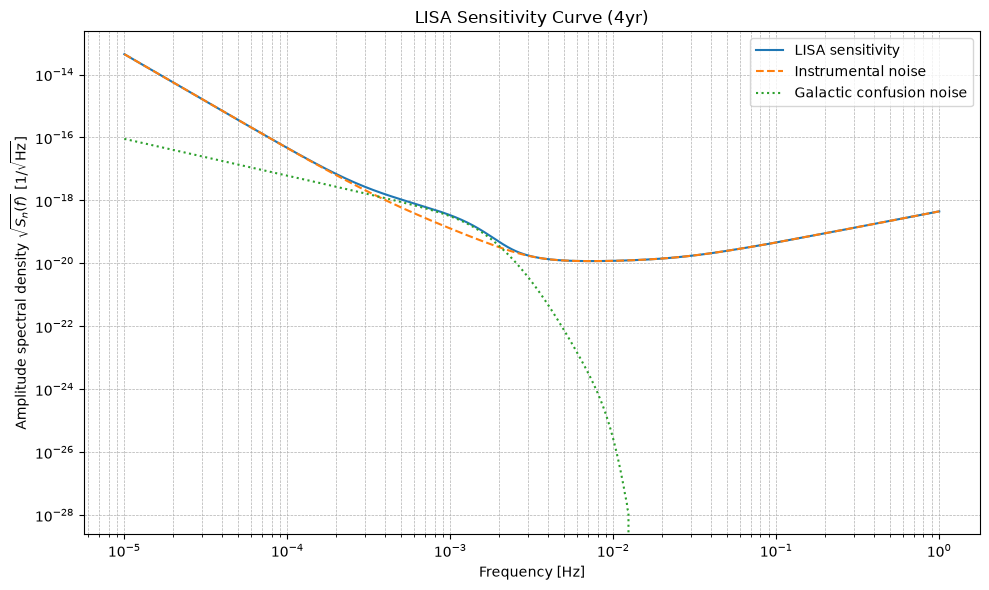

In [5]:
# Plot the amplitude spectral density.
lisa.plot(
    quantity="asd",
    show_components=True,
)

Figure saved as: lisa_sensitivity_4yr.png


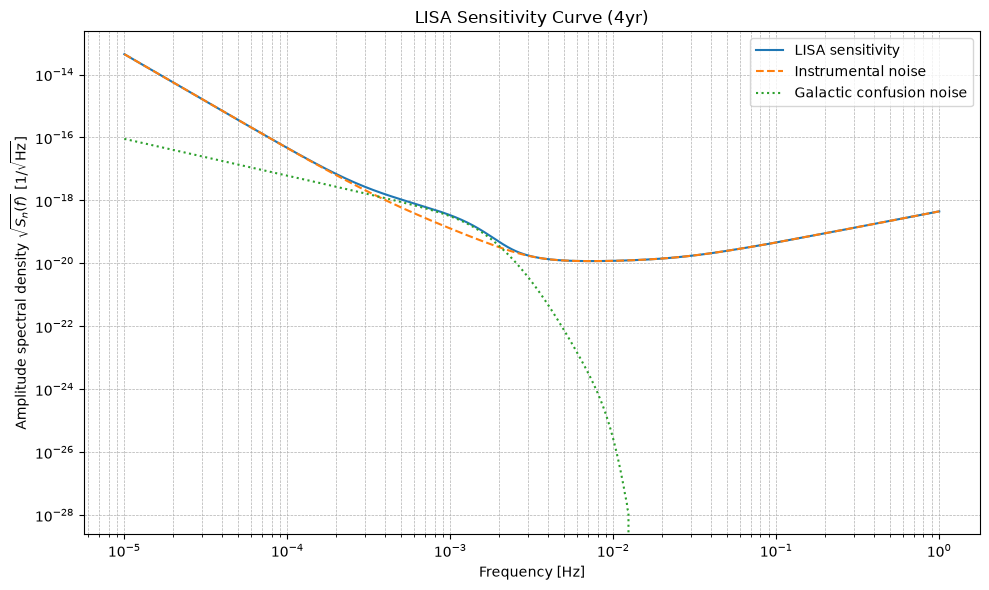

In [6]:
lisa.plot(
    quantity="asd",
    show_components=True,
    save_fig=True,
    filename="lisa_sensitivity_4yr.png",
)

## Test for LISA sensitivity at waveform frequencies

In [7]:
# Example frequency array representing output from a waveform model.
waveform_frequencies = np.logspace(
    np.log10(1e-4),
    np.log10(1e-1),
    500,
)

In [8]:
from SensaLISA import LISASensitivityFromWaveform

In [9]:
# Calculate LISA noise at the waveform frequencies.
lisa_waveform = LISASensitivityFromWaveform(
    frequencies=waveform_frequencies,
    observation_time="4yr",
)

frequencies, noise_psd = lisa_waveform.get_psd()
_, noise_asd = lisa_waveform.get_asd()

print("Number of waveform frequencies:", len(frequencies))
print(f"Minimum waveform frequency: {frequencies[0]:.4e} Hz")
print(f"Maximum waveform frequency: {frequencies[-1]:.4e} Hz")

print("\nFirst five waveform frequencies:")
print(frequencies[:5])

print("\nFirst five LISA noise PSD values:")
print(noise_psd[:5])


Number of waveform frequencies: 500
Minimum waveform frequency: 1.0000e-04 Hz
Maximum waveform frequency: 1.0000e-01 Hz

First five waveform frequencies:
[0.0001     0.00010139 0.00010281 0.00010424 0.00010569]

First five LISA noise PSD values:
[2.15102189e-33 1.98505050e-33 1.83205198e-33 1.69100485e-33
 1.56096842e-33]


In [10]:
# Confirm that the class preserves the input frequency array.
assert frequencies.shape == waveform_frequencies.shape
assert np.allclose(frequencies, waveform_frequencies)

# Check the calculated noise.
assert np.all(np.isfinite(noise_psd))
assert np.all(noise_psd > 0)
assert np.allclose(noise_asd, np.sqrt(noise_psd))

print("\nWaveform-frequency sensitivity test passed.")


Waveform-frequency sensitivity test passed.


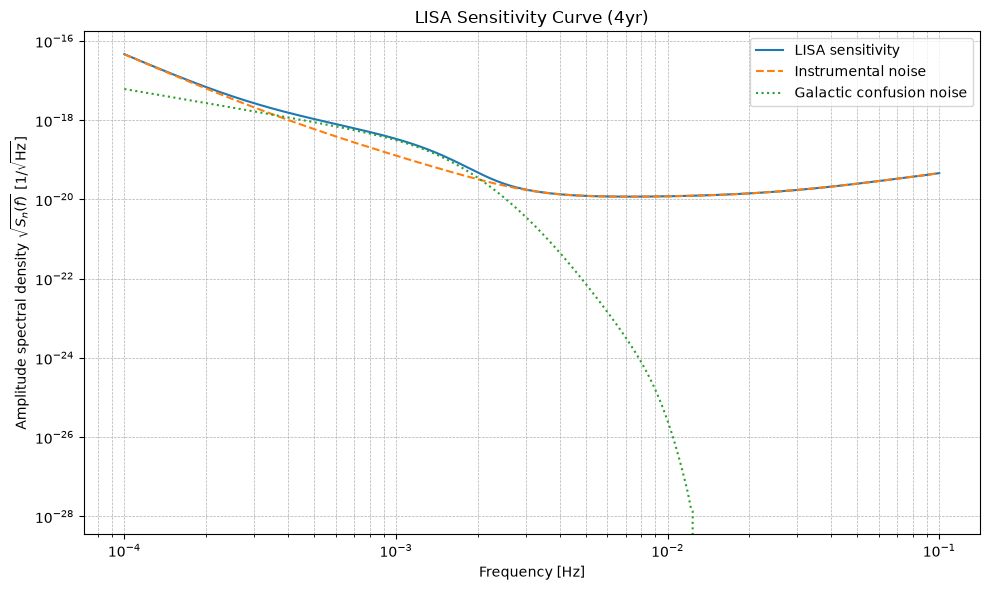

In [11]:
# Plot LISA sensitivity at the waveform frequencies.
lisa_waveform.plot(
    quantity="asd",
    show_components=True,
)

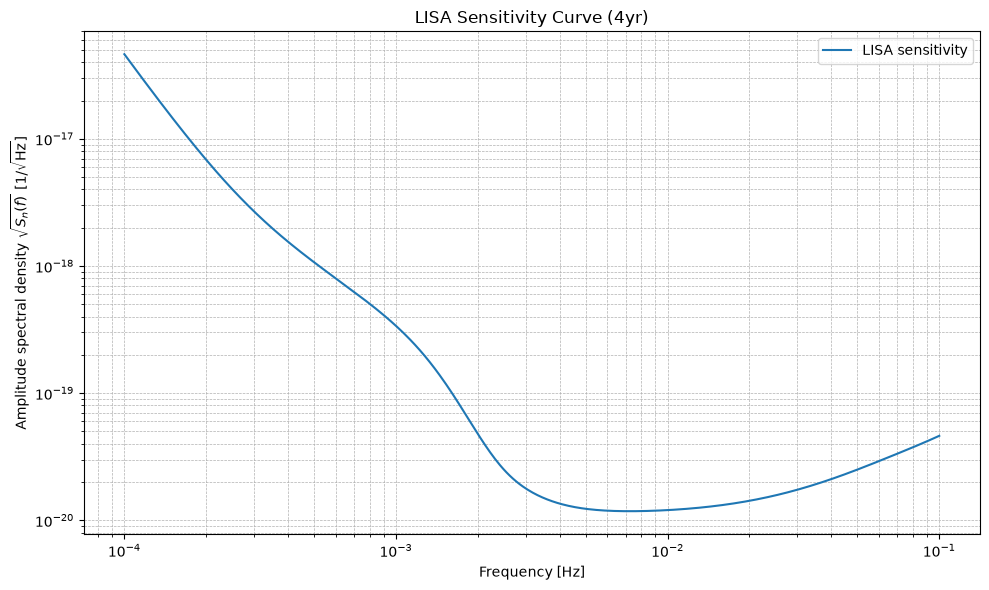

In [12]:
# Plot LISA sensitivity at the waveform frequencies.
lisa_waveform.plot(
    quantity="asd",
)

Figure saved as: lisa_characteristic_strain.png


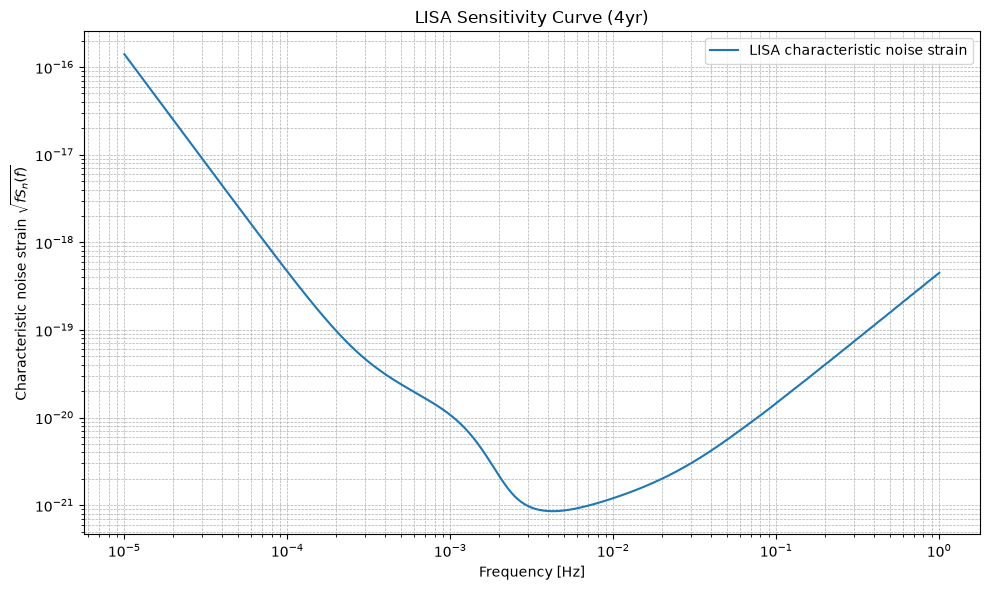

In [13]:
lisa.plot(
    quantity="characteristic_strain",
    save_fig=True,
    filename="lisa_characteristic_strain.png",
)